In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from scipy.stats import gaussian_kde

In [2]:
## Output folder for figures
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

In [3]:
## Load stability metrics
data = pd.read_csv('processed_data/crossyear_nnd_summary.csv', parse_dates=['date_now', 'date_prev'])
randomisations = pd.read_csv('processed_data/crossyear_nnd_with_randomisations.csv', parse_dates=['date_now', 'date_prev'])
pointwise = pd.read_csv('processed_data/crossyear_nnd_pointwise.csv', parse_dates=['date_curr', 'date_prev']).rename(columns={'date_curr': 'date_now'})
pointwise_randomisations = pd.read_csv('processed_data/crossyear_nnd_pointwise_randomisations.csv', parse_dates=['date_now', 'date_prev'])

## Factor ordering + labels
lek_labels = ['Tal Chhapar', 'Velavadar Lek 1', 'Velavadar Lek 2']

data['lek_id'] = (pd.Categorical(data['lek_id'],categories=lek_labels,ordered=True).rename_categories(lek_labels))
randomisations['lek_id'] = (pd.Categorical(randomisations['lek_id'],categories=lek_labels,ordered=True).rename_categories(lek_labels))
pointwise['lek_id'] = (pd.Categorical(pointwise['lek_id'],categories=lek_labels,ordered=True).rename_categories(lek_labels))
pointwise_randomisations['lek_id'] = (pd.Categorical(pointwise_randomisations['lek_id'],categories=lek_labels,ordered=True).rename_categories(lek_labels))

In [4]:
## Colour palettes
fill_cols = {'Tal Chhapar': '#B5542D', 'Velavadar Lek 1': '#1F6F8B', 'Velavadar Lek 2': '#3FA7A3'}
point_cols = {'Tal Chhapar': '#D97A52', 'Velavadar Lek 1': '#15556B', 'Velavadar Lek 2': '#2B7E7B'}

lek_labels = data['lek_id'].cat.categories.tolist()

In [5]:
def log_kde_on_original_scale(y, xs, bw_method=0.2, eps=1e-6):
    y = y[np.isfinite(y)]
    y = y[y > 0]

    z = np.log(y + eps)
    kde = gaussian_kde(z, bw_method=bw_method)

    xs_pos = np.maximum(xs, eps)
    density = kde(np.log(xs_pos + eps)) / (xs_pos + eps)

    return density

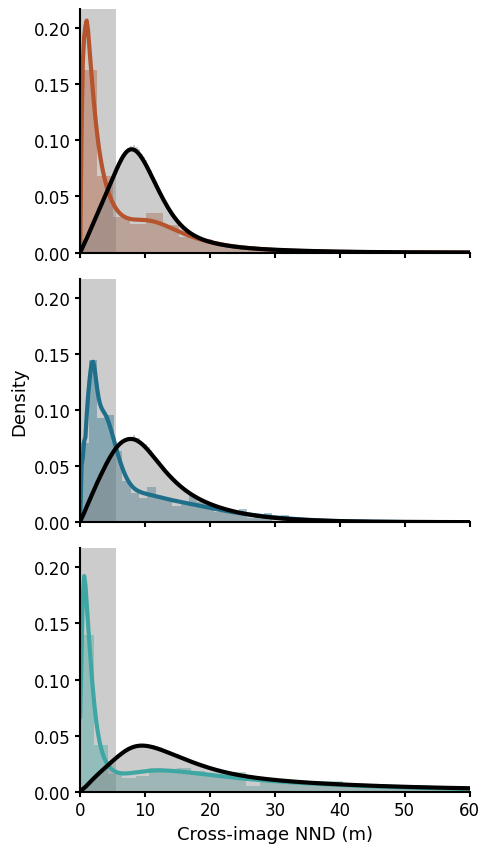

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(5, 9), sharex=True, sharey=True)
bin_dict = {'Velavadar Lek 1': 30, 'Velavadar Lek 2': 60, 'Tal Chhapar': 20}
for ax, lek in zip(axes, lek_labels):
    obs = pointwise.loc[pointwise['lek_id'] == lek, 'nnd_to_prev'].to_numpy()
    rand = pointwise_randomisations.loc[pointwise_randomisations['lek_id'] == lek, 'nnd_to_prev'].to_numpy()

    # Plot data and randomisation
    ax.hist(obs, bins=bin_dict[lek], density=True, color=fill_cols[lek], alpha=0.4)
    ax.hist(rand, bins='fd', density=True, color='grey',alpha=0.4)

    # Add KDEs for data and randomisation   
    xs = np.linspace(0.01, 60, 300)

    ys_obs = log_kde_on_original_scale(obs, xs)
    ys_rand = log_kde_on_original_scale(rand, xs)

    ax.plot(xs, ys_obs, color=fill_cols[lek], linewidth=3)
    ax.plot(xs, ys_rand, color='black', linewidth=3)
    ax.axvspan(0, 5.538, color='black', alpha=0.2, ec=None, linewidth=0, zorder=0)

    ax.set_xlim(0,60)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

axes[1].set_ylabel('Density', fontsize=13)
axes[-1].set_xlabel('Cross-image NND (m)', fontsize=13)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(out_dir/'external_memory_distribution.png', dpi=300, bbox_inches='tight')

In [7]:
for lek in lek_labels:
    print(len(pointwise.loc[(pointwise['lek_id'] == lek) & (pointwise['nnd_to_prev'] < 5.538),:]) / len(pointwise.loc[pointwise['lek_id'] == lek,:]), ' ', len(pointwise_randomisations.loc[(pointwise_randomisations['lek_id'] == lek) & (pointwise_randomisations['nnd_to_prev'] < 5.654),:]) / len(pointwise_randomisations.loc[pointwise_randomisations['lek_id'] == lek,:]))
    
    print(lek, pointwise.loc[(pointwise['lek_id'] == lek), 'nnd_to_prev'].median(), pointwise_randomisations.loc[(pointwise_randomisations['lek_id'] == lek), 'nnd_to_prev'].median())

0.5998552821997105   0.20175832127351664
Tal Chhapar 3.6462616061765774 9.011895448957251
0.5449826989619377   0.19927508650519032
Velavadar Lek 1 4.878744065182471 9.77573857493119
0.40804597701149425   0.08326580459770115
Velavadar Lek 2 11.585586971364714 17.014972199902203
